In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive

/content/drive/MyDrive


In [4]:
ls

 checkpoints/        __MACOSX/               taxi_drop/
'Colab Notebooks'/   nyc-taxi.h5             taxi_drop.zip
 KDD2022@            rain_impact_zones.png   w_texi_drop/


# Data Preprocess & DataLoader

In [5]:
import numpy as np
import os
import torch
from torch.utils.data import TensorDataset, DataLoader

class StandardScaler:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return (data * self.std) + self.mean

def load_dataset(dataset_dir, batch_size, valid_batch_size=None, test_batch_size=None):
    data = {}
    for category in ["train", "val", "test"]:
        cat_data = np.load(os.path.join(dataset_dir, category + ".npz"))
        data["x_" + category] = cat_data["x"]
        data["y_" + category] = cat_data["y"]

    scaler = StandardScaler(
        mean=data["x_train"][..., 0].mean(), std=data["x_train"][..., 0].std()
    )
    for category in ["train", "val", "test"]:
        data["x_" + category][..., 0] = scaler.transform(data["x_" + category][..., 0])

    train_ds = TensorDataset(torch.Tensor(data["x_train"]), torch.Tensor(data["y_train"]))
    val_ds   = TensorDataset(torch.Tensor(data["x_val"]),   torch.Tensor(data["y_val"]))
    test_ds  = TensorDataset(torch.Tensor(data["x_test"]),  torch.Tensor(data["y_test"]))

    loader_kwargs = dict(num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
    data["train_loader"] = DataLoader(train_ds, batch_size=batch_size,      shuffle=True,  **loader_kwargs)
    data["val_loader"]   = DataLoader(val_ds,   batch_size=valid_batch_size, shuffle=False, **loader_kwargs)
    data["test_loader"]  = DataLoader(test_ds,  batch_size=test_batch_size,  shuffle=False, **loader_kwargs)
    data["scaler"] = scaler
    return data


In [ ]:
# """测试dataLoader模块"""
# dataset_dir = "taxi_drop"
# taxi_drop_data = load_dataset(dataset_dir, batch_size=32, valid_batch_size=32, test_batch_size=32)

In [ ]:
# example_x, example_y = next(iter(taxi_drop_data["train_loader"]))
# print("Example x shape:", example_x.shape)  # (batch_size, num_time_steps, locations, channels)
# print("Example y shape:", example_y.shape)  # (batch_size, num_time_steps, locations, 1)

Example x shape: torch.Size([32, 12, 266, 3])
Example y shape: torch.Size([32, 12, 266, 1])


In [ ]:
# example_x[0,0,100,:]

# ST_LLM Model

In [6]:
import torch
import torch.nn as nn
from transformers.models.gpt2.modeling_gpt2 import GPT2Model


class TemporalEmbedding(nn.Module):
    def __init__(self, time, n_embd):
        super().__init__()
        self.day = time
        self.time_day = nn.Embedding(time, n_embd)
        self.time_week = nn.Embedding(7, n_embd)
        nn.init.xavier_uniform_(self.time_day.weight)
        nn.init.xavier_uniform_(self.time_week.weight)
    

    def forward(self, x): # x shape: (B, P, N, C)
        # 获取输入数据所在的设备 (cuda:0 或 cpu)
        device = x.device 

        # --- 处理 Day Embedding ---
        day_info = x[..., 1]  # (B, P, N)
        # 显式使用 .to(device) 确保索引在 GPU 上
        day_idx = (day_info[:, -1, :] * self.day).long().clamp(0, self.day - 1).to(device)
        day_embd = self.time_day(day_idx)                      # (B, N, n_embd)
        day_embd = day_embd.transpose(1, 2).unsqueeze(-1)      # (B, n_embd, N, 1)

        # --- 处理 Week Embedding ---
        week_info = x[..., 2]  # (B, P, N)
        # 同样显式指定设备
        week_idx = week_info[:, -1, :].long().clamp(0, 6).to(device)
        week_embd = self.time_week(week_idx)                   # (B, N, n_embd)
        week_embd = week_embd.transpose(1, 2).unsqueeze(-1)    # (B, n_embd, N, 1)

        return day_embd + week_embd  # (B, n_embd, N, 1)
    

class SpatialEmbedding(nn.Module):
    def __init__(self, num_locations, n_embd):
        super().__init__()
        self.num_locations = num_locations
        self.location_embd = nn.Embedding(num_locations, n_embd)
        nn.init.xavier_uniform_(self.location_embd.weight)

    def forward(self, x):  # x shape: (B, P, N, C)
        B = x.shape[0]
        # 核心修改：显式指定 device
        device = x.device 
        indices = torch.arange(self.num_locations, device=device)
        
        node_emb = self.location_embd(indices) # (N, n_embd)
        node_emb = node_emb.unsqueeze(0).expand(B, -1, -1).transpose(1, 2).unsqueeze(-1)  # (B, n_embd, N, 1)

        return node_emb  # (B, n_embd, N, 1)

class TokenEmbedding(nn.Module):
    def __init__(self, input_dim = 3, input_len = 12, n_embd = 256):
        super().__init__()
        #卷積：（B，256，H，W)
        self.in_channels = input_dim * input_len # 3个通道，每个通道12个时间步，展开后是36维
        self.tk_embd = nn.Conv2d(in_channels=self.in_channels, out_channels=n_embd, kernel_size=1) #卷积核大小为1
        

    def forward(self, x): # x shape: (B, P, N, C)
        B, P, N, C = x.shape
        x = x[..., :3] # 取前3个通道，(B, P, N, 3)
        x = x.permute(0, 3, 1, 2) # (B, C, P, N)
        x = x.reshape(B, -1, N)    # (B, C*P, N)
        tk_embd = self.tk_embd(x.unsqueeze(-1)) # (B, n_embd, N, 1)

        return tk_embd # (B, n_embd, N, 1)

class WeatherEmbedding(nn.Module):
    def __init__(self, input_len, n_embd):
        super().__init__()
        self.w_embd = nn.Conv2d(in_channels = input_len, out_channels = n_embd, kernel_size = 1)

    def forward(self,x):
        w_info = x[:,:,:,3] #(B, P, N)
        w_embd = self.w_embd(w_info.unsqueeze(-1))
        
        return w_embd # (B, n_embd, N, 1)


class PFA(nn.Module):
    def __init__(self, gpt_layers = 6, U = 1): 
        super().__init__()
        self.gpt2 = GPT2Model.from_pretrained("gpt2")
        #保留中間的attention權重：self.gpt2 = GPT2Model.from_pretrained("gpt2", output_attentions=True, output_hidden_states=True）
        self.gpt2.h = self.gpt2.h[:gpt_layers] #保留前gpt_layers层，注意原始的gpt2是12層
        self.U = U #每个位置的邻居数量

        # frooze 和 learning 的 param调整
        for layer_idx, layer in enumerate(self.gpt2.h):
            for name, param in layer.named_parameters():
                if layer_idx < gpt_layers - self.U:  #所有層數 - 不凍結attention的層數,前幾層
                    #TODO: wpe是什么
                    if "ln" in name: # LayerNorm层
                        param.requires_grad = True
                    else:
                        param.requires_grad = False
                else: #最後U層，attn也要打開
                    if "mlp" in name:
                        param.requires_grad = False
                    else:
                        param.requires_grad = True

    def forward(self, x): # x shape: (batch_size, num_time_steps, locations, n_embd)
        return self.gpt2(inputs_embeds = x).last_hidden_state
    

class ST_LLM(nn.Module):
    def __init__(self, batch_size = 32, num_nodes = 266, input_len = 12, output_len = 12, gpt_layers = 6, U = 1):
        super().__init__()
        self.batch_size = batch_size
        self.num_nodes = num_nodes #location数量
        self.input_len = input_len
        self.output_len = output_len
        self.gpt_layers = gpt_layers
        self.U = U
        self.time = 48      #一天中的时间段数量
        self.n_embd = 256   #时间，空间，token三个拼一起，3*256=768
        self.gpt_embd = 768 #embedding维度，和GPT-2的默认维度一致
        #embedding
        self.time_embd = TemporalEmbedding(self.time, self.n_embd) #时间编码模块
        self.spatial_embd = SpatialEmbedding(self.num_nodes, self.n_embd) #空间编码模块
        self.token_embd = TokenEmbedding(input_dim=3, input_len=self.input_len, n_embd=self.n_embd) #token embedding, 将原始的3个通道映射到n_embd维度

        self.weather_embd = WeatherEmbedding(input_len= self.input_len, n_embd = self.n_embd)
        
        #聚合embedding
        self.feature_fuse = nn.Conv2d(in_channels=4*self.n_embd, out_channels=self.gpt_embd, kernel_size=1) #特征融合，卷积核大小为1，输入（B，xxx，H，W）
        #PFA
        self.pfa = PFA(gpt_layers=self.gpt_layers, U=self.U)
        #最后解码成预测结果
        self.regression_layer = nn.Conv2d(in_channels=self.gpt_embd, out_channels=self.output_len, kernel_size=1) #卷积核大小为1，输入（B，gpt_embd，H，W）
        

    def forward(self, history_data):    # x shape: (B, P, N, C)
        input_data = history_data
        B, P, N, C = input_data.shape

        #embedding
        time_embd = self.time_embd(input_data) # (B, n_embd, N, 1)
        spatial_embd = self.spatial_embd(input_data) # (B, n_embd, N, 1)
        token_embd = self.token_embd(input_data) # (B, n_embd, N, 1)

        weather_embd = self.weather_embd(input_data)
        #feature fusing
        embd_feature = torch.cat([token_embd, time_embd, spatial_embd, weather_embd], dim=1) # (B, 4*n_embd, N, 1)
        data_feature = self.feature_fuse(embd_feature) # (B, gpt_embd,N,1)
        data_feature = data_feature.squeeze(-1).permute(0, 2, 1) # (B, N, gpt_embd)

        #PFA
        pfa_out = self.pfa(data_feature) # (B, N, gpt_embd)

        #最終預測
        pfa_out = pfa_out.permute(0, 2, 1).unsqueeze(-1) # (B, gpt_embd, N, 1)

        pred = self.regression_layer(pfa_out) # (B, output_len, N, 1)
        pred = pred.squeeze(-1) # (B, output_len, N)
        
        return pred


# STLLM辅助

In [5]:
import torch
import torch.nn as nn
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

In [6]:
"""時間embedding:包含一天中的时间段和一周中的星期几信息"""
#輸入： x : (B, P, N, C) B: batch_size, P：历史时间步数，N：位置数量，C：通道数量
#輸出： time_embedding shape: (B, n_embd, N, 1)
class TemporalEmbedding(nn.Module):
    def __init__(self, time, n_embd):
        super().__init__()
        self.day = time
        self.time_day = nn.Embedding(time, n_embd)
        self.time_week = nn.Embedding(7, n_embd)
        nn.init.xavier_uniform_(self.time_day.weight)
        nn.init.xavier_uniform_(self.time_week.weight)
    

    def forward(self, x): # x shape: (B, P, N, C)
        # 获取输入数据所在的设备 (cuda:0 或 cpu)
        device = x.device 

        # --- 处理 Day Embedding ---
        day_info = x[..., 1]  # (B, P, N)
        # 显式使用 .to(device) 确保索引在 GPU 上
        day_idx = (day_info[:, -1, :] * self.day).long().clamp(0, self.day - 1).to(device)
        day_embd = self.time_day(day_idx)                      # (B, N, n_embd)
        day_embd = day_embd.transpose(1, 2).unsqueeze(-1)      # (B, n_embd, N, 1)

        # --- 处理 Week Embedding ---
        week_info = x[..., 2]  # (B, P, N)
        # 同样显式指定设备
        week_idx = week_info[:, -1, :].long().clamp(0, 6).to(device)
        week_embd = self.time_week(week_idx)                   # (B, N, n_embd)
        week_embd = week_embd.transpose(1, 2).unsqueeze(-1)    # (B, n_embd, N, 1)

        return day_embd + week_embd  # (B, n_embd, N, 1)


In [7]:
"""空間 embedding：每個地點學習一個獨立的向量"""
# 輸入： x : (B, P, N, C)
# 輸出： (B, n_embd, N, 1)
    
class SpatialEmbedding(nn.Module):
    def __init__(self, num_locations, n_embd):
        super().__init__()
        self.num_locations = num_locations
        self.location_embd = nn.Embedding(num_locations, n_embd)
        nn.init.xavier_uniform_(self.location_embd.weight)

    def forward(self, x):  # x shape: (B, P, N, C)
        B = x.shape[0]
        # 核心修改：显式指定 device
        device = x.device 
        indices = torch.arange(self.num_locations, device=device)
        
        node_emb = self.location_embd(indices) # (N, n_embd)
        node_emb = node_emb.unsqueeze(0).expand(B, -1, -1).transpose(1, 2).unsqueeze(-1)  # (B, n_embd, N, 1)

        return node_emb  # (B, n_embd, N, 1)


In [8]:
"""信息embedding：利用卷積融合流量+時間+空間信息"""
class TokenEmbedding(nn.Module):
    def __init__(self, input_dim = 3, input_len = 12, n_embd = 256):
        super().__init__()
        #卷積：（B，256，H，W)
        self.in_channels = input_dim * input_len # 3个通道，每个通道12个时间步，展开后是36维
        self.tk_embd = nn.Conv2d(in_channels=self.in_channels, out_channels=n_embd, kernel_size=1) #卷积核大小为1
        

    def forward(self, x): # x shape: (B, P, N, C)
        B, P, N, C = x.shape
        x = x.permute(0, 3, 1, 2) # (B, C, P, N)
        x = x.reshape(B, -1, N)    # (B, C*P, N)
        tk_embd = self.tk_embd(x.unsqueeze(-1)) # (B, n_embd, N, 1)

        return tk_embd # (B, n_embd, N, 1)

In [25]:
'''测试embedding模块'''
# # random_data = example_x # (batch_size, num_time_steps, locations, channels)
# token_embd = TokenEmbedding(input_dim=3, input_len=12, n_embd=256)
# temporal_embd = TemporalEmbedding(time=48, n_embd=256)
# spatial_embd = SpatialEmbedding(num_locations=266, n_embd=256)
# tk_embd = token_embd(example_x)
# print("Token Embedding shape:", tk_embd.shape)  
# sp_embd = spatial_embd(example_x)
# print("Spatial Embedding shape", sp_embd.shape)  # (B, n_embd, N, 1)
# tp_embd = temporal_embd(example_x)
# print("Temporal Embedding shape:", tp_embd.shape)  # (B, n_embd, N, 1)
# embd_feature = torch.cat([tk_embd,tp_embd,sp_embd], dim=1) # (B, 3*n_embd, N, 1)
# print(embd_feature.shape)
# fusion = nn.Conv2d(768,768,kernel_size=(1,1))
# data_feature = fusion(embd_feature)
# print(data_feature.shape)

'测试embedding模块'

In [9]:
'''部分冻结的大语言模型'''
#GPT2Block包含：
# - ln_1: LayerNorm
# - attn: GPT2Attention
# - ln_2: LayerNorm
# - mlp: GPT2MLP
# 原始一共12层
# GPT2輸入： batch, sequence_length, embedding_dim
# TODO:這個地方用序列建模合理嗎？
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

class PFA(nn.Module):
    def __init__(self, gpt_layers = 6, U = 1): 
        super().__init__()
        self.gpt2 = GPT2Model.from_pretrained("gpt2")
        #保留中間的attention權重：self.gpt2 = GPT2Model.from_pretrained("gpt2", output_attentions=True, output_hidden_states=True）
        self.gpt2.h = self.gpt2.h[:gpt_layers] #保留前gpt_layers层，注意原始的gpt2是12層
        self.U = U #每个位置的邻居数量

        # frooze 和 learning 的 param调整
        for layer_idx, layer in enumerate(self.gpt2.h):
            for name, param in layer.named_parameters():
                if layer_idx < gpt_layers - self.U:  #所有層數 - 不凍結attention的層數,前幾層
                    #TODO: wpe是什么
                    if "ln" in name: # LayerNorm层
                        param.requires_grad = True
                    else:
                        param.requires_grad = False
                else: #最後U層，attn也要打開
                    if "mlp" in name:
                        param.requires_grad = False
                    else:
                        param.requires_grad = True

    def forward(self, x): # x shape: (batch_size, num_time_steps, locations, n_embd)
        return self.gpt2(inputs_embeds = x).last_hidden_state

In [27]:
"""測繪pfa模塊"""
# in_data = torch.randn(32, 266, 768) # (B, N, gpt_embd)
# pfa = PFA(gpt_layers=6, U=1)
# out_data = pfa(in_data)
# print("PFA output shape:", out_data.shape)  # (B, N, gpt_embd)

'測繪pfa模塊'

In [10]:
class ST_LLM(nn.Module):
    def __init__(self, batch_size = 32, num_nodes = 266, input_len = 12, output_len = 12, gpt_layers = 6, U = 1):
        super().__init__()
        self.batch_size = batch_size
        self.num_nodes = num_nodes #location数量
        self.input_len = input_len
        self.output_len = output_len
        self.gpt_layers = gpt_layers
        self.U = U
        self.time = 48      #一天中的时间段数量
        self.n_embd = 256   #时间，空间，token三个拼一起，3*256=768
        self.gpt_embd = 768 #embedding维度，和GPT-2的默认维度一致
        #embedding
        self.time_embd = TemporalEmbedding(self.time, self.n_embd) #时间编码模块
        self.spatial_embd = SpatialEmbedding(self.num_nodes, self.n_embd) #空间编码模块
        self.token_embd = TokenEmbedding(input_dim=3, input_len=self.input_len, n_embd=self.n_embd) #token embedding, 将原始的3个通道映射到n_embd维度
        #聚合embedding
        self.feature_fuse = nn.Conv2d(in_channels=3*self.n_embd, out_channels=self.gpt_embd, kernel_size=1) #特征融合，卷积核大小为1，输入（B，xxx，H，W）
        #PFA
        self.pfa = PFA(gpt_layers=self.gpt_layers, U=self.U)
        #最后解码成预测结果
        self.regression_layer = nn.Conv2d(in_channels=self.gpt_embd, out_channels=self.output_len, kernel_size=1) #卷积核大小为1，输入（B，gpt_embd，H，W）
        

    def forward(self, history_data):    # x shape: (B, P, N, C)
        input_data = history_data
        B, P, N, C = input_data.shape

        #embedding
        time_embd = self.time_embd(input_data) # (B, n_embd, N, 1)
        spatial_embd = self.spatial_embd(input_data) # (B, n_embd, N, 1)
        token_embd = self.token_embd(input_data) # (B, n_embd, N, 1)

        #feature fusing
        embd_feature = torch.cat([token_embd, time_embd, spatial_embd], dim=1) # (B, 3*n_embd, N, 1)
        data_feature = self.feature_fuse(embd_feature) # (B, gpt_embd,N,1)
        data_feature = data_feature.squeeze(-1).permute(0, 2, 1) # (B, N, gpt_embd)

        #PFA
        pfa_out = self.pfa(data_feature) # (B, N, gpt_embd)

        #最終預測
        pfa_out = pfa_out.permute(0, 2, 1).unsqueeze(-1) # (B, gpt_embd, N, 1)

        pred = self.regression_layer(pfa_out) # (B, output_len, N, 1)
        pred = pred.squeeze(-1) # (B, output_len, N)
        
        return pred

In [ ]:
# """测试ST_LLM模型"""
# model = ST_LLM(batch_size=32, num_nodes=266, input_len=12, output_len=12, gpt_layers=6, U=1)
# pred = model(example_x) # (B, output_len, N, 1)
# print("Prediction shape:", pred.shape)  # (B, output_len, N, 1)
# scaler = taxi_drop_data['scaler']
# prediction = scaler.inverse_transform(pred) #还原到原始尺度
# print("Inverse transformed prediction shape:", prediction.shape)  # (B, output_len, N)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prediction shape: torch.Size([32, 12, 266])
Inverse transformed prediction shape: torch.Size([32, 12, 266])


# Train

In [12]:
# train — ST-LLM baseline
import torch
import torch.nn as nn
import numpy as np
import logging
import time
import os
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

torch.manual_seed(313)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# ── 超参数 ────────────────────────────────────────────────────────────────────
batch_size  = 64
lrate       = 1e-4
wdecay      = 1e-5
epochs      = 300
num_nodes   = 266
input_len   = 12
output_len  = 12
gpt_layers  = 6
U           = 1
dataset_dir = "w_texi_drop"
SAVE_DIR    = "./checkpoints"
SAVE_AFTER  = 20
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Logger ────────────────────────────────────────────────────────────────────
def get_logger(log_path):
    logger = logging.getLogger("st_llm")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    fmt = logging.Formatter("%(asctime)s  %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
    fh = logging.FileHandler(log_path, mode="a", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)
    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    return logger

# ── 指标计算 ──────────────────────────────────────────────────────────────────
def calc_metrics(pred, real):
    mae  = np.mean(np.abs(pred - real))
    mse  = np.mean((pred - real) ** 2)
    rmse = np.sqrt(mse)
    mask = real != 0
    mape = np.mean(np.abs((pred[mask] - real[mask]) / real[mask])) * 100
    wape = np.sum(np.abs(pred - real)) / np.sum(np.abs(real)) * 100
    return {"mae": mae, "mse": mse, "rmse": rmse, "mape": mape, "wape": wape}

# ── Trainer ───────────────────────────────────────────────────────────────────
class trainer:
    def __init__(self, scaler, learning_rate, wdecay,
                 num_nodes, input_len, output_len, gpt_layers, U):
        self.scaler     = scaler
        self.amp_scaler = GradScaler()
        self.model = ST_LLM(batch_size=batch_size, num_nodes=num_nodes,
                            input_len=input_len, output_len=output_len,
                            gpt_layers=gpt_layers, U=U).to(device)
        self.model = torch.compile(self.model)
        self.optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=learning_rate, weight_decay=wdecay)
        self.criterion = nn.MSELoss()

    def train_loop(self, x, y):
        self.model.train()
        self.optimizer.zero_grad(set_to_none=True)
        with autocast():
      
            output = self.model(x)
            pred   = self.scaler.inverse_transform(output).unsqueeze(-1)
            loss   = self.criterion(pred, y)
        self.amp_scaler.scale(loss).backward()
        self.amp_scaler.step(self.optimizer)
        self.amp_scaler.update()
        return loss.item()

    def eval_loop(self, x, y):
        self.model.eval()
        with torch.no_grad(), autocast():
            output = self.model(x)
            pred   = self.scaler.inverse_transform(output).unsqueeze(-1)
            loss   = self.criterion(pred, y)
        return loss.item(), pred, y

# ── 评估整个 loader ───────────────────────────────────────────────────────────
def evaluate(engine, loader):
    loss_list, preds, reals = [], [], []
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        loss, p, r = engine.eval_loop(x_batch, y_batch)
        loss_list.append(loss)
        preds.append(p)
        reals.append(r)
    pred_all = torch.cat(preds).cpu().numpy()
    real_all = torch.cat(reals).cpu().numpy()
    metrics  = calc_metrics(pred_all, real_all)
    metrics["loss"] = np.mean(loss_list)
    return metrics

# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    log_path  = os.path.join(SAVE_DIR, "st-llm.log")
    ckpt_path = os.path.join(SAVE_DIR, "st-llm_best.pt")
    logger    = get_logger(log_path)

    dataloader = load_dataset(dataset_dir, batch_size=batch_size,
                              valid_batch_size=batch_size, test_batch_size=batch_size)

    if "test_loader" not in dataloader:
        loader_kwargs = dict(num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
        cat_data = np.load(os.path.join(dataset_dir, "test.npz"))
        x_test = cat_data["x"].copy()
        x_test[..., 0] = dataloader["scaler"].transform(x_test[..., 0])
        test_ds = TensorDataset(torch.Tensor(x_test), torch.Tensor(cat_data["y"]))
        dataloader["test_loader"] = DataLoader(test_ds, batch_size=batch_size,
                                               shuffle=False, **loader_kwargs)
        print("test_loader created manually")

    engine = trainer(scaler=dataloader["scaler"], learning_rate=lrate, wdecay=wdecay,
                     num_nodes=num_nodes, input_len=input_len, output_len=output_len,
                     gpt_layers=gpt_layers, U=U)

    logger.info("=" * 60)
    logger.info(f"ST-LLM Baseline | epochs={epochs} lr={lrate} wd={wdecay}")
    logger.info(f"gpt_layers={gpt_layers}  U={U}  batch={batch_size}  save_after={SAVE_AFTER}")
    logger.info("=" * 60)
    logger.info(f"{'Epoch':>6}  {'TrainLoss':>10}  {'MAE':>8}  {'MSE':>10}  {'MAPE%':>8}  {'WAPE%':>8}  {'Time':>7}  Note")

    best_val_mae = float("inf")

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_losses = []
        for x_batch, y_batch in tqdm(dataloader["train_loader"],
                                     desc=f"Epoch {epoch:>3}/{epochs}",
                                     leave=False, dynamic_ncols=True):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss = engine.train_loop(x_batch, y_batch)
            train_losses.append(loss)

        val_m      = evaluate(engine, dataloader["val_loader"])
        epoch_time = time.time() - t0

        tag = ""
        if epoch > SAVE_AFTER and val_m["mae"] < best_val_mae:
            best_val_mae = val_m["mae"]
            torch.save(engine.model.state_dict(), ckpt_path)
            tag = "★ best"

        logger.info(
            f"{epoch:>6}/{epochs}  "
            f"{np.mean(train_losses):>10.4f}  "
            f"{val_m['mae']:>8.4f}  "
            f"{val_m['mse']:>10.4f}  "
            f"{val_m['mape']:>8.2f}  "
            f"{val_m['wape']:>8.2f}  "
            f"{epoch_time:>6.1f}s  {tag}"
        )

    # ── 最终 Test 评估 ────────────────────────────────────────────────────────
    logger.info("=" * 60)
    logger.info(f"Loading best checkpoint  (best val MAE={best_val_mae:.4f})")
    state_dict = torch.load(ckpt_path, map_location=device)
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    engine.model.load_state_dict(state_dict)

    test_m = evaluate(engine, dataloader["test_loader"])
    logger.info(
        f"[TEST]  MAE={test_m['mae']:.4f}  MSE={test_m['mse']:.4f}  "
        f"RMSE={test_m['rmse']:.4f}  MAPE={test_m['mape']:.2f}%  WAPE={test_m['wape']:.2f}%"
    )
    logger.info("=" * 60)

if __name__ == "__main__":
    main()


Using Device: cuda


/tmp/ipykernel_10112/3956698188.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_scaler = GradScaler()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-28 03:27:49  ============================================================
INFO:st_llm:============================================================
2026-04-28 03:27:49  ST-LLM Baseline | epochs=300 lr=0.0001 wd=1e-05
INFO:st_llm:ST-LLM Baseline | epochs=300 lr=0.0001 wd=1e-05
2026-04-28 03:27:49  gpt_layers=6  U=1  batch=64  save_after=20
INFO:st_llm:gpt_layers=6  U=1  batch=64  save_after=20
2026-04-28 03:27:49  ============================================================
INFO:st_llm:============================================================
2026-04-28 03:27:49   Epoch   TrainLoss       MAE         MSE     MAPE%     WAPE%     Time  Note
INFO:st_llm: Epoch   TrainLoss       MAE         MSE     MAPE%     WAPE

RuntimeError: Error(s) in loading state_dict for OptimizedModule:
	Missing key(s) in state_dict: "_orig_mod.time_embd.time_day.weight", "_orig_mod.time_embd.time_week.weight", "_orig_mod.spatial_embd.location_embd.weight", "_orig_mod.token_embd.tk_embd.weight", "_orig_mod.token_embd.tk_embd.bias", "_orig_mod.weather_embd.w_embd.weight", "_orig_mod.weather_embd.w_embd.bias", "_orig_mod.feature_fuse.weight", "_orig_mod.feature_fuse.bias", "_orig_mod.pfa.gpt2.wte.weight", "_orig_mod.pfa.gpt2.wpe.weight", "_orig_mod.pfa.gpt2.h.0.ln_1.weight", "_orig_mod.pfa.gpt2.h.0.ln_1.bias", "_orig_mod.pfa.gpt2.h.0.attn.c_attn.weight", "_orig_mod.pfa.gpt2.h.0.attn.c_attn.bias", "_orig_mod.pfa.gpt2.h.0.attn.c_proj.weight", "_orig_mod.pfa.gpt2.h.0.attn.c_proj.bias", "_orig_mod.pfa.gpt2.h.0.ln_2.weight", "_orig_mod.pfa.gpt2.h.0.ln_2.bias", "_orig_mod.pfa.gpt2.h.0.mlp.c_fc.weight", "_orig_mod.pfa.gpt2.h.0.mlp.c_fc.bias", "_orig_mod.pfa.gpt2.h.0.mlp.c_proj.weight", "_orig_mod.pfa.gpt2.h.0.mlp.c_proj.bias", "

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: ./checkpoints/st-llm_best.pt


/tmp/ipykernel_2783/1364600939.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[ALL]    MAE=5.1140  RMSE=9.0949  MAPE=39.57%  WAPE=20.44%
[RAINY]  MAE=5.1685                   MAPE=38.00%  WAPE=19.31%
[DRY]    MAE=5.1012                   MAPE=39.91%  WAPE=20.70%
Rainy samples: 135  |  Dry samples: 724


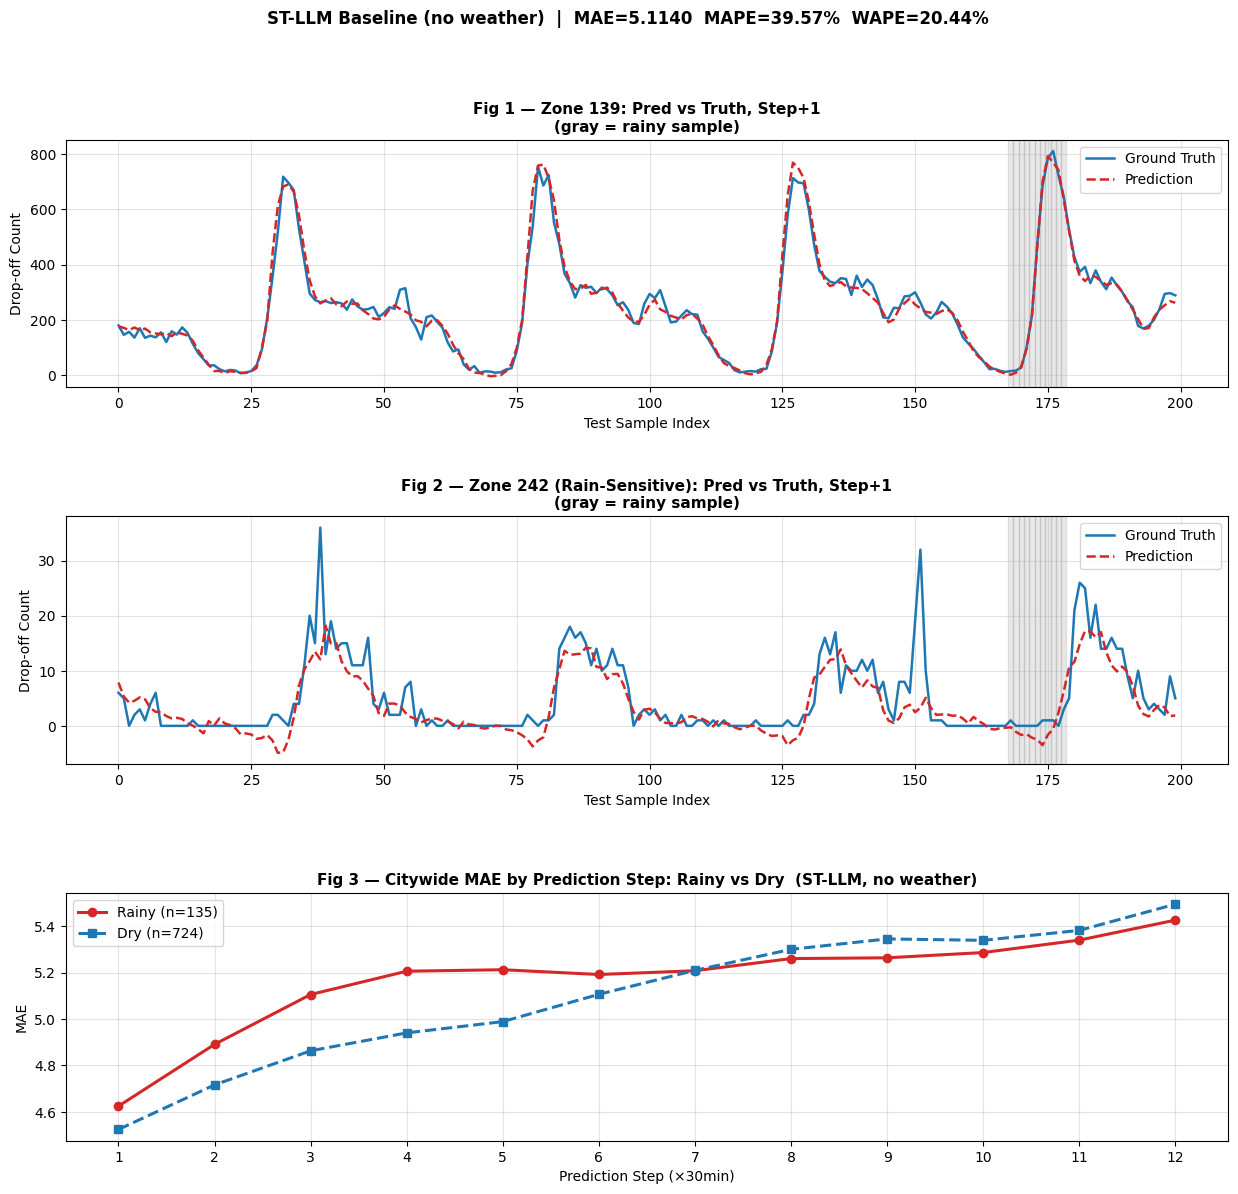

Saved: ./checkpoints/stllm_inference_vis.png

[Fig 3 Data Points]
 Step   Rainy MAE     Dry MAE
  +01        4.6247      4.5241
  +02        4.8911      4.7163
  +03        5.1060      4.8633
  +04        5.2065      4.9405
  +05        5.2129      4.9892
  +06        5.1923      5.1068
  +07        5.2085      5.2100
  +08        5.2610      5.3009
  +09        5.2643      5.3456
  +10        5.2870      5.3397
  +11        5.3405      5.3825
  +12        5.4267      5.4954


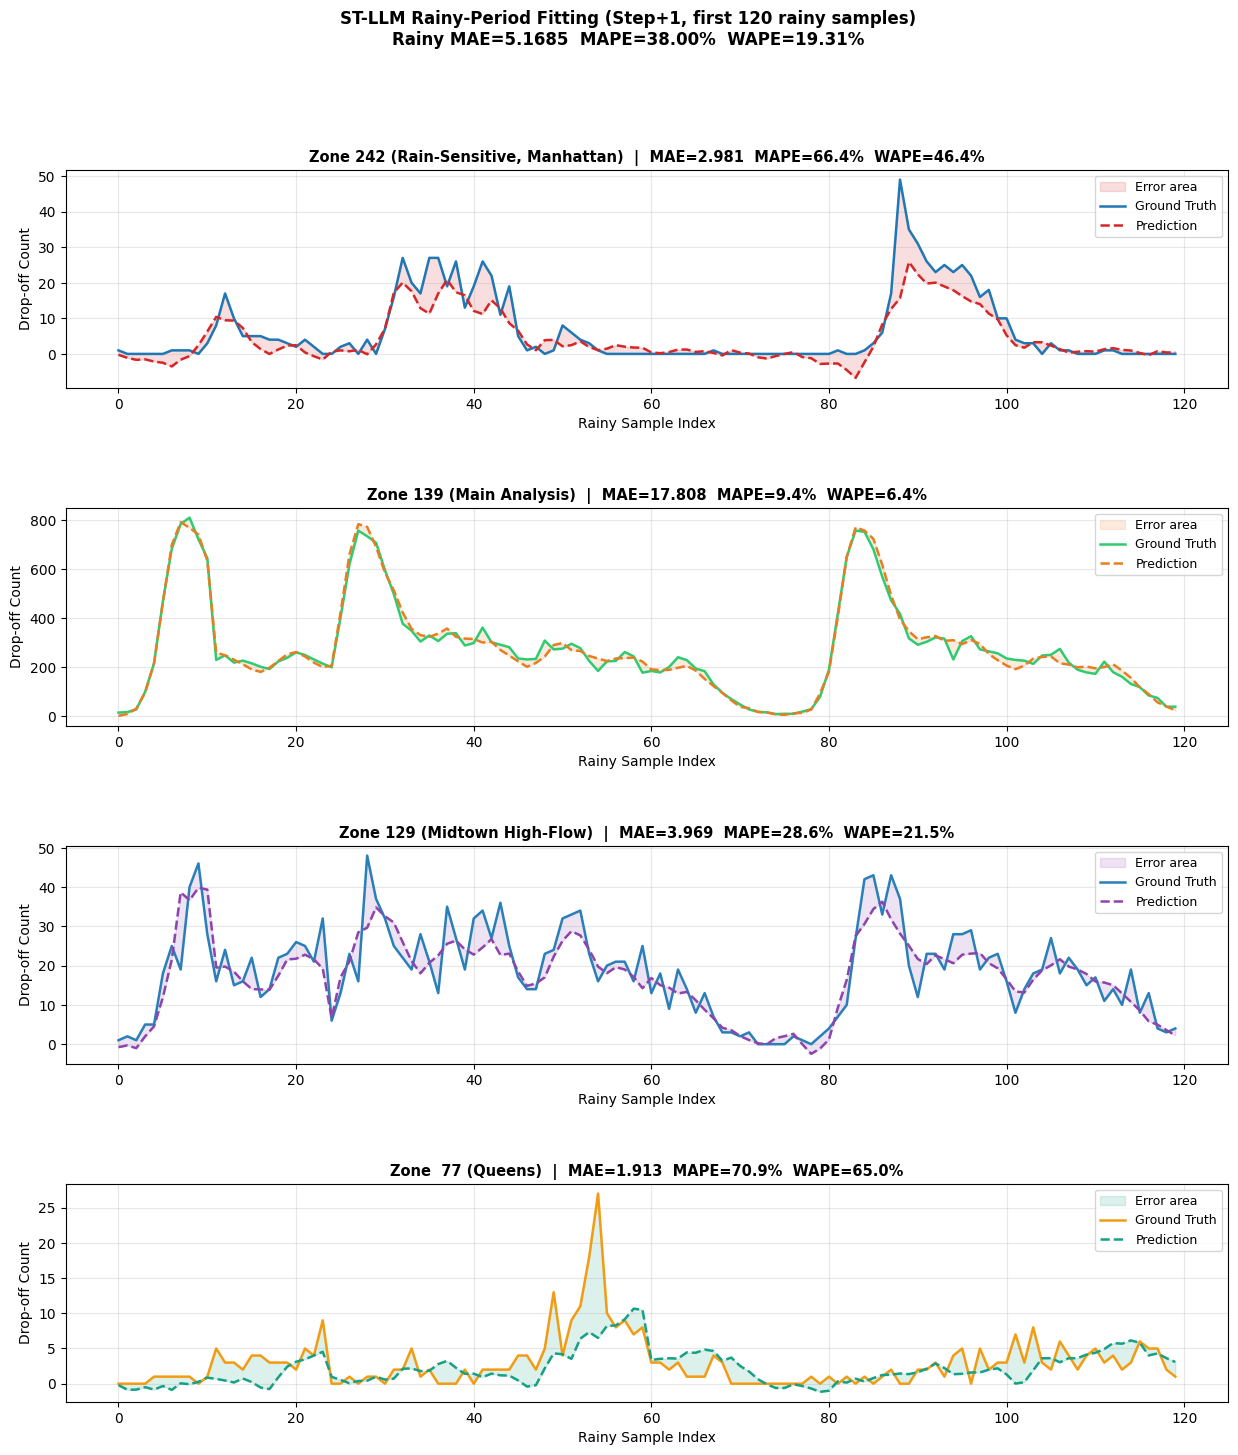

Saved: ./checkpoints/stllm_rainy_zones.png

[Rainy-Period Zone Metrics  (Step+1)]
    Zone       MAE     MAPE%     WAPE%
     242     2.8241     70.49     49.07
     139    17.6753     11.51      6.33
     129     3.8685     30.63     21.81
      77     1.8480     71.84     67.80


In [9]:
# ── ST-LLM Inference on w_texi_drop：Zone 139 & Zone 242 可视化 ──────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast

CKPT_PATH   = "./checkpoints/st-llm_best.pt"
DATASET_DIR = "w_texi_drop"
ZONE_A      = 139
ZONE_B      = 242
N_SHOW      = 200

torch.manual_seed(313)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ── 加载测试数据 ──────────────────────────────────────────────────────────────
cat_data   = np.load(os.path.join(DATASET_DIR, "test.npz"))
train_data = np.load(os.path.join(DATASET_DIR, "train.npz"))
x_test_raw = cat_data["x"].astype(np.float32)
y_test_raw = cat_data["y"].astype(np.float32)

flow_mean = train_data["x"][..., 0].mean()
flow_std  = train_data["x"][..., 0].std()

x_test = x_test_raw.copy()
x_test[..., 0] = (x_test[..., 0] - flow_mean) / flow_std

# ── 加载模型 ──────────────────────────────────────────────────────────────────
infer_model = ST_LLM(batch_size=64, num_nodes=266,
                     input_len=12, output_len=12, gpt_layers=6, U=1).to(device)
sd = torch.load(CKPT_PATH, map_location=device)
sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
infer_model.load_state_dict(sd)
infer_model.eval()
print(f"Loaded: {CKPT_PATH}")

# ── 推理 ──────────────────────────────────────────────────────────────────────
loader = DataLoader(TensorDataset(torch.Tensor(x_test), torch.Tensor(y_test_raw)),
                    batch_size=64, shuffle=False)
all_preds, all_reals, all_rain_cov = [], [], []

with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device)
        with autocast():
            out = infer_model(xb)
        pred = (out.cpu().numpy() * flow_std + flow_mean)
        real = yb.squeeze(-1).numpy()
        rain_cov = (xb[:, :, :, 3] > 0).float().mean(dim=(1, 2)).cpu().numpy()
        all_preds.append(pred); all_reals.append(real); all_rain_cov.append(rain_cov)

preds     = np.concatenate(all_preds,    axis=0)
reals     = np.concatenate(all_reals,    axis=0)
rain_covs = np.concatenate(all_rain_cov, axis=0)

# ── 分组 & 指标 ───────────────────────────────────────────────────────────────
rainy_mask = rain_covs > 0.1
dry_mask   = rain_covs == 0.0
rainy_idx  = np.where(rainy_mask)[0]   # 雨天样本的全局索引

mae_all  = np.mean(np.abs(preds - reals))
rmse_all = np.sqrt(np.mean((preds - reals) ** 2))
mask_nz  = reals != 0
mape_all = np.mean(np.abs((preds[mask_nz] - reals[mask_nz]) / reals[mask_nz])) * 100
wape_all = np.sum(np.abs(preds - reals)) / np.sum(np.abs(reals)) * 100

mae_rain  = np.mean(np.abs(preds[rainy_mask] - reals[rainy_mask])) if rainy_mask.sum() > 0 else float('nan')
mae_dry   = np.mean(np.abs(preds[dry_mask]   - reals[dry_mask]))   if dry_mask.sum()   > 0 else float('nan')
mask_r_nz = reals[rainy_mask] != 0
mape_rain = np.mean(np.abs((preds[rainy_mask][mask_r_nz] - reals[rainy_mask][mask_r_nz])
                            / reals[rainy_mask][mask_r_nz])) * 100 if rainy_mask.sum() > 0 else float('nan')
wape_rain = (np.sum(np.abs(preds[rainy_mask] - reals[rainy_mask]))
             / np.sum(np.abs(reals[rainy_mask]))) * 100             if rainy_mask.sum() > 0 else float('nan')
mask_d_nz = reals[dry_mask] != 0
mape_dry  = np.mean(np.abs((preds[dry_mask][mask_d_nz] - reals[dry_mask][mask_d_nz])
                            / reals[dry_mask][mask_d_nz])) * 100   if dry_mask.sum() > 0 else float('nan')
wape_dry  = (np.sum(np.abs(preds[dry_mask] - reals[dry_mask]))
             / np.sum(np.abs(reals[dry_mask]))) * 100               if dry_mask.sum() > 0 else float('nan')

print("=" * 60)
print(f"[ALL]    MAE={mae_all:.4f}  RMSE={rmse_all:.4f}  MAPE={mape_all:.2f}%  WAPE={wape_all:.2f}%")
print(f"[RAINY]  MAE={mae_rain:.4f}                   MAPE={mape_rain:.2f}%  WAPE={wape_rain:.2f}%")
print(f"[DRY]    MAE={mae_dry:.4f}                   MAPE={mape_dry:.2f}%  WAPE={wape_dry:.2f}%")
print(f"Rainy samples: {rainy_mask.sum()}  |  Dry samples: {dry_mask.sum()}")
print("=" * 60)

# ── Fig 1-3：原有图 ───────────────────────────────────────────────────────────
fig, axs = plt.subplots(3, 1, figsize=(15, 13))
plt.subplots_adjust(hspace=0.52)
fig.suptitle(
    f'ST-LLM Baseline (no weather)  |  MAE={mae_all:.4f}  MAPE={mape_all:.2f}%  WAPE={wape_all:.2f}%',
    fontsize=12, fontweight='bold')

for ax, zone_id, title in [
    (axs[0], ZONE_A, f'Fig 1 — Zone {ZONE_A}: Pred vs Truth, Step+1'),
    (axs[1], ZONE_B, f'Fig 2 — Zone {ZONE_B} (Rain-Sensitive): Pred vs Truth, Step+1'),
]:
    t = np.arange(N_SHOW)
    ax.plot(t, reals[:N_SHOW, 0, zone_id], color='#1f77b4', lw=1.8, label='Ground Truth')
    ax.plot(t, preds[:N_SHOW, 0, zone_id], color='#d62728', lw=1.8, ls='--', label='Prediction')
    for i in range(N_SHOW):
        if rainy_mask[i]:
            ax.axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.18)
    ax.set_title(f'{title}\n(gray = rainy sample)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Sample Index'); ax.set_ylabel('Drop-off Count')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.35)

ax = axs[2]
steps  = np.arange(1, 13)
rain_s = [np.mean(np.abs(preds[rainy_mask, s, :] - reals[rainy_mask, s, :])) for s in range(12)]
dry_s  = [np.mean(np.abs(preds[dry_mask,   s, :] - reals[dry_mask,   s, :])) for s in range(12)]
ax.plot(steps, rain_s, color='#d62728', lw=2.2, marker='o', label=f'Rainy (n={rainy_mask.sum()})')
ax.plot(steps, dry_s,  color='#1f77b4', lw=2.2, marker='s', ls='--', label=f'Dry (n={dry_mask.sum()})')
ax.set_title('Fig 3 — Citywide MAE by Prediction Step: Rainy vs Dry  (ST-LLM, no weather)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Prediction Step (×30min)'); ax.set_ylabel('MAE')
ax.set_xticks(steps); ax.legend(fontsize=10); ax.grid(True, alpha=0.35)

plt.savefig('./checkpoints/stllm_inference_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./checkpoints/stllm_inference_vis.png")

# ── Fig 3 数据点打印 ──────────────────────────────────────────────────────────
print("\n[Fig 3 Data Points]")
print(f"{'Step':>5}  {'Rainy MAE':>10}  {'Dry MAE':>10}")
for s in range(12):
    print(f"  +{s+1:02d}    {rain_s[s]:>10.4f}  {dry_s[s]:>10.4f}")

# ── Fig 4：雨天时段各区域拟合图（仅展示雨天样本）────────────────────────────
# 选区依据：
#   Zone 242 — 已知雨敏感高流量区
#   Zone 139 — 本notebook主要分析区
#   Zone 129 — 中城高流量（Grand Central 附近）
#   Zone  77 — 皇后区，对降雨反应不同于曼哈顿
RAIN_ZONES = [242, 139, 129, 77]
RAIN_ZONE_LABELS = {
    242: 'Zone 242 (Rain-Sensitive, Manhattan)',
    139: 'Zone 139 (Main Analysis)',
    129: 'Zone 129 (Midtown High-Flow)',
     77: 'Zone  77 (Queens)',
}

# 取前 min(120, n_rainy) 个雨天样本，避免图太密
n_rain_show = min(120, len(rainy_idx))
show_idx    = rainy_idx[:n_rain_show]   # 原始样本索引
t_rain      = np.arange(n_rain_show)   # 雨天样本的连续序号

fig2, axs2 = plt.subplots(len(RAIN_ZONES), 1, figsize=(15, 4 * len(RAIN_ZONES)))
plt.subplots_adjust(hspace=0.55)
fig2.suptitle(
    f'ST-LLM Rainy-Period Fitting (Step+1, first {n_rain_show} rainy samples)\n'
    f'Rainy MAE={mae_rain:.4f}  MAPE={mape_rain:.2f}%  WAPE={wape_rain:.2f}%',
    fontsize=12, fontweight='bold')

colors_pred  = ['#d62728', '#e67e22', '#8e44ad', '#16a085']
colors_truth = ['#1f77b4', '#2ecc71', '#2980b9', '#f39c12']

for i, (zone_id, c_pred, c_truth) in enumerate(zip(RAIN_ZONES, colors_pred, colors_truth)):
    ax = axs2[i]
    truth_zone = reals[show_idx, 0, zone_id]
    pred_zone  = preds[show_idx, 0, zone_id]
    err        = np.abs(pred_zone - truth_zone)

    ax.fill_between(t_rain, truth_zone, pred_zone,
                    alpha=0.15, color=c_pred, label='Error area')
    ax.plot(t_rain, truth_zone, color=c_truth, lw=1.8, label='Ground Truth')
    ax.plot(t_rain, pred_zone,  color=c_pred,  lw=1.8, ls='--', label='Prediction')

    zone_mae  = err.mean()
    mask_z_nz = truth_zone != 0
    zone_mape = np.mean(np.abs((pred_zone[mask_z_nz] - truth_zone[mask_z_nz])
                                / truth_zone[mask_z_nz])) * 100 if mask_z_nz.sum() > 0 else float('nan')
    zone_wape = np.sum(err) / np.sum(np.abs(truth_zone)) * 100

    ax.set_title(
        f'{RAIN_ZONE_LABELS[zone_id]}  |  MAE={zone_mae:.3f}  MAPE={zone_mape:.1f}%  WAPE={zone_wape:.1f}%',
        fontsize=10.5, fontweight='bold')
    ax.set_xlabel('Rainy Sample Index'); ax.set_ylabel('Drop-off Count')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.savefig('./checkpoints/stllm_rainy_zones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./checkpoints/stllm_rainy_zones.png")

# ── 打印各雨天区域指标 ─────────────────────────────────────────────────────────
print("\n[Rainy-Period Zone Metrics  (Step+1)]")
print(f"{'Zone':>8}  {'MAE':>8}  {'MAPE%':>8}  {'WAPE%':>8}")
for zone_id in RAIN_ZONES:
    t_z    = reals[rainy_idx, 0, zone_id]
    p_z    = preds[rainy_idx, 0, zone_id]
    m_mae  = np.mean(np.abs(p_z - t_z))
    nz     = t_z != 0
    m_mape = np.mean(np.abs((p_z[nz] - t_z[nz]) / t_z[nz])) * 100 if nz.sum() > 0 else float('nan')
    m_wape = np.sum(np.abs(p_z - t_z)) / np.sum(np.abs(t_z)) * 100
    print(f"  {zone_id:>6}   {m_mae:>8.4f}  {m_mape:>8.2f}  {m_wape:>8.2f}")
